# Часть 1. Проверка гипотезы в Python и составление аналитической записки

**ТЗ**  
Загрузить данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv.  
Проверить наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Необходимо статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовить аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Напишите заголовок первой части проекта здесь
- Автор: SVM
- Дата: 03.10.2026


## Цели и задачи проекта

Целью проекта является проверка гипотезы, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

## Описание данных
<font color='#777778'>Исходные данные представлены в датасете "yandex_knigi_data.csv".
Датасет содержит содержит три колонки  
`city` - принадлежность пользователей к городам  
`puid` - идентификатор пользователя  
`hours` - колличество часов, потраченным пользователем над книгами  
</font>


## Содержимое проекта
- Загрузка данных и знамоство с ними
- Предобработка данных
- Проверка на пропуски и дубликаты
- Проверка на аномалии и выбросы
- Распределение дискретных данных
- Проверка гипотезы в Python
- Аналитическая записка

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest # для расчета Z-теста пропорций

In [2]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/yandex_knigi_data.csv', index_col = 0)
df.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [3]:
df.tail()

,city,puid,hours
8779,Санкт-Петербург,1130000028554332,4.107774
8780,Санкт-Петербург,1130000030307246,45.069222
8781,Санкт-Петербург,1130000038726322,0.211944
8782,Санкт-Петербург,1130000047892100,4.311841
8783,Санкт-Петербург,1130000061443598,20.847222


In [4]:
# Информация о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 274.5+ KB


In [5]:
# Проверка на полные дубликаты
print(f'Количество полных дубликатов {df.duplicated().sum()}')
# Проверка на дубликаты по идентификатору пользователя puid
v_sum_dup_puid = df.duplicated(subset='puid').sum()
print(f'Количество дубликатов по идентификатору пользователя(puid): {v_sum_dup_puid}')
# Проверка на дубликаты по ключу city, puid
v_sum_dup_all = df.duplicated(subset=['city', 'puid']).sum()
print(f'Количество дубликатов по по ключу city, puid: {v_sum_dup_all}')

Количество полных дубликатов 0
Количество дубликатов по идентификатору пользователя(puid): 244
Количество дубликатов по по ключу city, puid: 0


In [6]:
# Есть дубликаты по идентификатору пользователя(puid), причем такие пользоваатели находятся в разных группах тестирования(Москва и СПБ)
# Это недопустимо, строки с выявленными puid необходимо удалить в обеих группах
print(f'Длина датафрейма до удаления дубликатов: {len(df)}')
df.drop_duplicates(subset='puid', keep=False, inplace=True)
df.reset_index(drop=True)
print(f'Длина датафрейма после удаления дубликатов {len(df)}')
# Финальная проверка на дубликаты
v_fin_check = df.duplicated().sum() + df.duplicated(subset=['puid']).sum() + df.duplicated(subset=['city', 'puid']).sum()
print(f'Количество дубликатов по всем признакам: {v_fin_check}')


Длина датафрейма до удаления дубликатов: 8784
Длина датафрейма после удаления дубликатов 8296
Количество дубликатов по всем признакам: 0


In [7]:
# Проверка на пересечение данных по городам
df_tmp = df[df['city']=='Москва'].rename(columns = {'puid':'puid_msk'}).copy()
df_tmp = df_tmp.merge(
df[df['city']=='Санкт-Петербург'], how='inner', left_on = 'puid_msk', right_on = 'puid', suffixes = ('_msk', '_spb')
)
df_tmp = df_tmp.rename(columns = {'puid':'puid_spb'})
print(f'Обнаружено {len(df_tmp)} пересечений')

Обнаружено 0 пересечений


**Проверка на аномалии и выбросы**

In [8]:
# Статистические показатели столбца hours
df['hours'].describe()

count    8296.000000
mean       10.963892
std        37.753906
min         0.000022
25%         0.057493
50%         0.884214
75%         5.944675
max       978.764775
Name: hours, dtype: float64

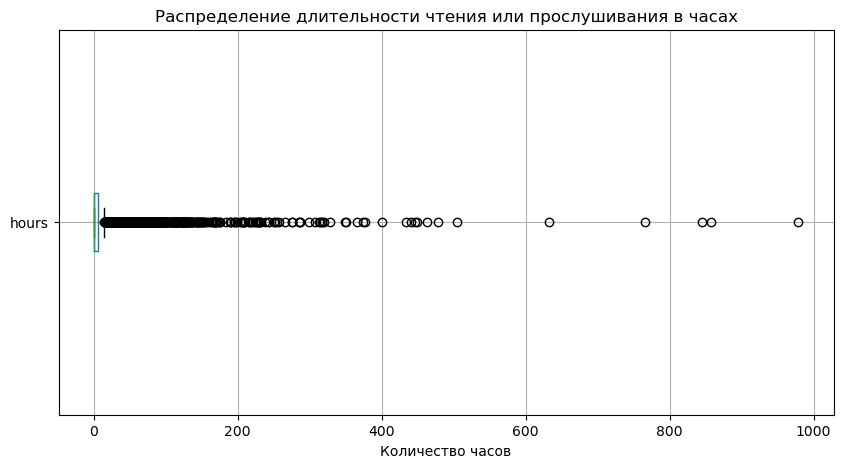

In [9]:
# Строим диаграмму размаха значений в столбце hours
plt.figure(figsize=(10, 5))

df.boxplot(column='hours', vert=False)

plt.title('Распределение длительности чтения или прослушивания в часах')
plt.xlabel('Количество часов')

# Выводим график
plt.show()

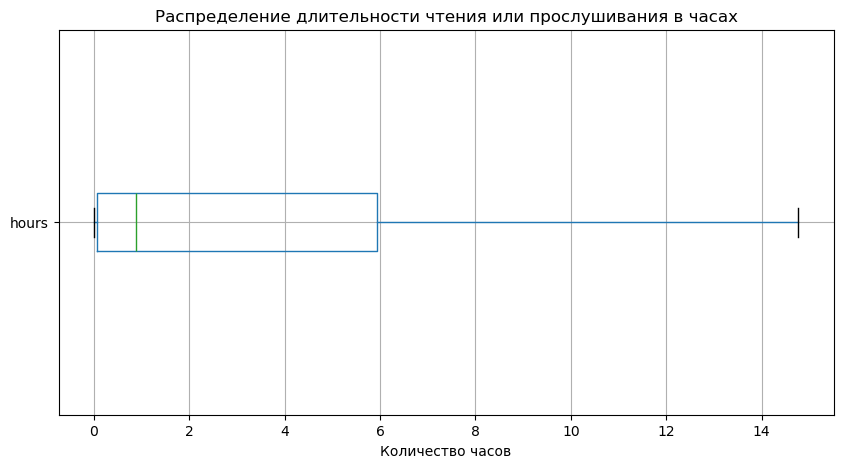

In [10]:
# Построим диаграмму размаха без аномалий
df.boxplot(column='hours',
                     vert=False, 
                     showfliers=False, 
                     figsize=(10, 5))

plt.title('Распределение длительности чтения или прослушивания в часах')
plt.xlabel('Количество часов')

plt.show()

Промежуточный вывод:  
В данных по длительности чтения/прослушивания имеются аномалии - это прослеживается на диаграмме размаха, а также прослеживаются большие различия между средним и медианным значениями, между минимальным и максимальным значениями. Медианным значением является длительность чтения/прослушивания около 1 часа (среднее - около 11 часов).

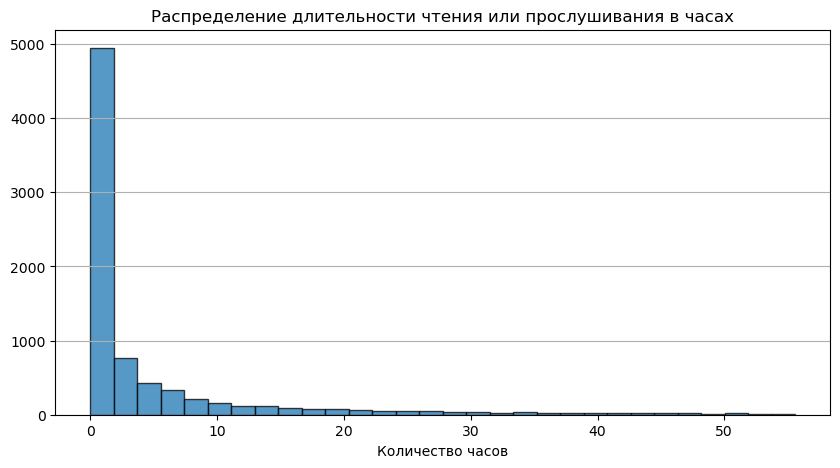

In [11]:
# Отфильтруем данные по 95 процентилю
filtered = df[df['hours'] <= df['hours'].quantile(0.95)]['hours']

plt.figure(figsize=(10, 5))

filtered.plot(kind='hist',
                bins=30,
                alpha=0.75,
                edgecolor='black',
)
plt.title('Распределение длительности чтения или прослушивания в часах')
plt.xlabel('Количество часов')
plt.ylabel('')
plt.grid(axis='y')
plt.show() 

In [12]:
# Отбираем данные, оставляя значения меньше 95 процентиля
df = df.loc[df['hours'] <  df['hours'].quantile(0.95)]
df = df.reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7881 entries, 0 to 7880
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    7881 non-null   object 
 1   puid    7881 non-null   int64  
 2   hours   7881 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 184.8+ KB


Промежуточный вывод:   
В датафрейме исключены выбросы/аномальные значения - данные отфильтрованы по 95 процентилю. В итоге осталось 7881 строка.

_**Предварительный вывод по качеству данных:**_  
- Исходный датафрейм не содержит пропусков
- Типы данных приемлемы для последующей обработки
- После предобработки данных датафрейм не содержит дубликатов
- Группы тестирования не пересекаются по ключевым значениям.
- В датафрейме исключены аномалии и выбросы. Для дальнейшей рарботы в рабочем датафрейме осталась 7881 строка
- Можно приступать к проверке гипотез.

**Распределение дискретных данных**

Количество пользователей в г. Москва: 5692
Количество пользователей в г. Санкт-Петербург: 2189


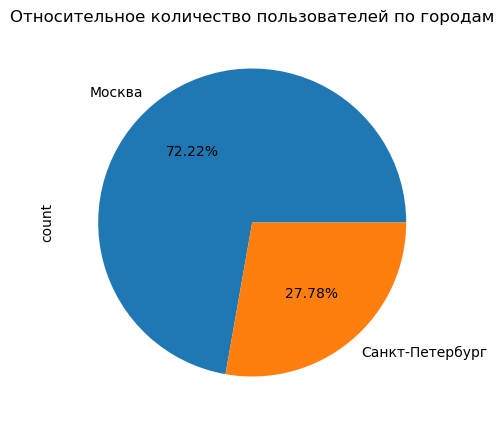

In [13]:
# Посмотрим на распределение количества пользователей по городам
v_msk = df[df['city'] == 'Москва']['puid'].nunique()
v_spb = df[df['city'] == 'Санкт-Петербург']['puid'].nunique()
print(f'Количество пользователей в г. Москва: {v_msk}')
print(f'Количество пользователей в г. Санкт-Петербург: {v_spb}')
df['city'].value_counts().plot(kind='pie',
                title='Относительное количество пользователей по городам',
                legend=False,
                figsize=(10, 5),
                autopct='%1.2f%%'
               )
plt.show()

Промежуточный вывод:  
В Москве (5692) количество пользователей значительно преобладает по сравнению с Санкт-Петербургом (2189). Группы распределены непропорционально (72% и 28% соответственно).

In [14]:
# Рассчитаем статистики в разрезе городов по столбцу hours - длительность чтения или прослушивания в часах
df.groupby('city').agg({'hours': ['sum','mean', 'max', 'min', 'median']})

hours                                         
                          sum      mean        max       min    median
city                                                                  
Москва           26419.077489  4.641440  55.577836  0.000022  0.721415
Санкт-Петербург  10883.181206  4.971759  55.451374  0.000025  0.678473

При разной суммарной длительности чтения/прослушивания в разрезе городов можно отметить, что средняя длительность прослушивания с Санкт-Петербурге выше (4,97 часа) по сравнению с Москвой (4,64 часа), а минимальное и максимальное время прослушивания практически не отличаются. Медианные значения сильно отличаются от средних.

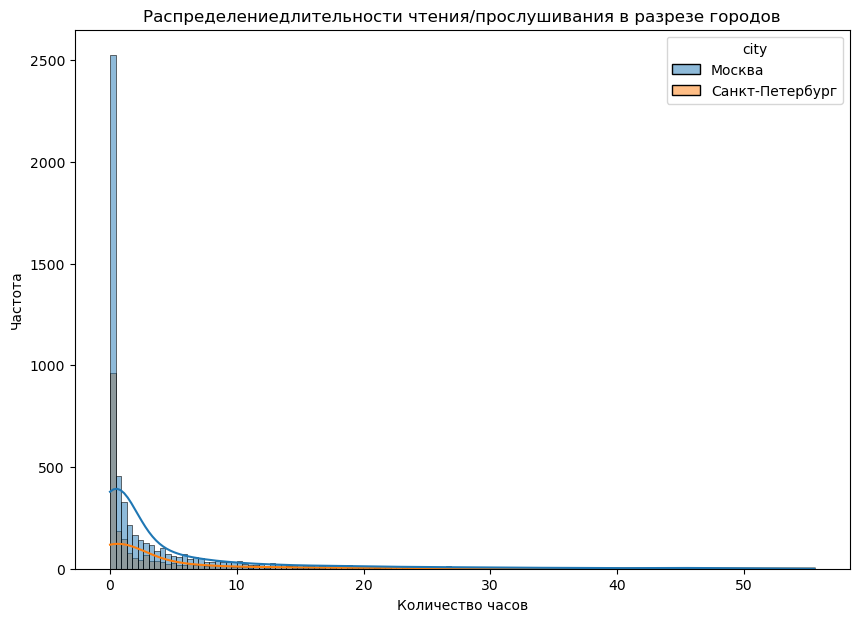

In [15]:
# Посмотрим как выглядят распределения часов прослушивания по городам
fig = plt.figure(figsize = (10, 7))
sns.histplot(data = df, x= 'hours', hue = 'city', kde = True)
plt.title('Распределениедлительности чтения/прослушивания в разрезе городов')
plt.xlabel('Количество часов')
plt.ylabel('Частота')
plt.show()

Распределения ассиметричные с длинными правыми хвостами (распределение отлично от нормального), но по форме распределения в городах похожи.

In [16]:
# Посчитаем дисперсии для городов
df[df['city'] == 'Москва']['hours'].var(), df[df['city'] == 'Санкт-Петербург']['hours'].var()

(82.17737537488233, 96.68738604505475)

_Дисперсии разные_

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

В качестве метрики используем среднее время чтения книг в городах  
В качестве инструмента проверки будем использовать t-test

In [17]:
metric_a = df[df['city'] == 'Москва']['hours'] 
metric_b = df[df['city'] == 'Санкт-Петербург']['hours'] 

alpha = 0.05
# Тест Уэлча (по умолчанию)
ttest_equal_pvalue = ttest_ind(metric_b, metric_a, equal_var=False, alternative='greater').pvalue

# Тест Стьюдента
ttest_pvalue = ttest_ind(metric_b, metric_a, alternative='greater').pvalue

print(f'ttest_pvalue={round(ttest_pvalue, 3)}'),
print(f'ttest_equal_pvalue={round(ttest_equal_pvalue, 3)}')

ttest_pvalue=0.079
ttest_equal_pvalue=0.086


## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



_**Вывод:**_  
_Для проверки гипотезы выбран уровень статистической значимости alpha = 0.05 и для сравнения проведены 2 статистических теста (t-тест Уэлча и тест Cтьюдента). В результате тестов получены значения: p-value = 0.086 (t-тест Уэлча) и p-value=0.079 (тест Стьюдента), которые больше уровня значимости 0,05, что свидетельствует нам об отсутствии доказательств отвергнуть нулевую гипотезу. Следовательно, средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается. Возможные причины полученных результатов: непропорциональное количество пользователей по городам, выбросы в данных, неравенство дисперсий._

# Часть 2. Анализ результатов A/B-тестирования

**ТЗ**  
Теперь нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Цели исследования.
Необходимо рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.


**Описание данных**  
https://code.s3.yandex.net/datasets/ab_test_participants.csv — таблица участников тестов.
Структура файла:
- `user_id` — идентификатор пользователя;
- `group` — группа пользователя;
- `ab_test` — название теста;
- `device` — устройство, с которого происходила регистрация.

https://code.s3.yandex.net/datasets/ab_test_events.zip — архив с одним csv-файлом, в котором собраны события 2020 года;
Структура файла:
- `user_id` — идентификатор пользователя;
- `event_dt` — дата и время события;
- `event_name` — тип события;
- `details` — дополнительные данные о событии.

**Содержимое проекта:**
- Загрузка данных и знакомство с ними
- Предобработка данных (при необходимости)
- Проверка на пропуски и дубликаты
- Оценка корректности проведения теста
- Аналитическая записка (результаты А/В теста)

## 2. Загрузка данные, оценка их целостности.


1. **Загрузка данных и знакомство с ними**

In [18]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [19]:
# Выводим первые строки датафрейма events на экран - посмотрим на исторические данные
events.head() 

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [20]:
# Выводим информацию о датафрейме
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


Датасет ab_test_events.zip содержит 4 столбца и 787286 строк. Названия столбцов соответствуют их содержимому. Колонка user_id содержит повторяющиеся значения "GLOBAL"(оставляю пока данный столбец как есть). Пропуски есть только в столбце details. Типы данных корректные.

2. **Проверка на пропуски и дубликаты**

In [21]:
# Подсчитываем долю строк с пропусками
events.isna().mean()

user_id       0.000000
event_dt      0.000000
event_name    0.000000
details       0.683696
dtype: float64

In [22]:
# Наличие явных дубликатов
print(f'Количество явных дубликатов: {events.duplicated().sum()}')
print(f'Доля явных дубликатов от всех строк датафрейма: {events.duplicated().sum()/len(events):1.3f} ')

Количество явных дубликатов: 36318
Доля явных дубликатов от всех строк датафрейма: 0.046 


In [23]:
# Проверим неявные дубликаты,которые могут быть по связке в столбцах user_id' и 'event_dt
print(events.duplicated(subset=['user_id', 'event_dt'], keep=False).sum())
v_frac = round(events.duplicated(subset=['user_id', 'event_dt'], keep=False).sum()/len(events), 3)
print(f'Доля неявных дубликатов: {v_frac}')

150653
Доля неявных дубликатов: 0.191


In [24]:
# Посмотрим на неявные дубликаты и сохраним их
duplicated = events[events[['user_id','event_dt']].duplicated(keep=False)].sort_values('user_id')
duplicated.head (10)

,user_id,event_dt,event_name,details
346516,000199F1887AE5E6,2020-12-15 07:28:44,product_page,NaN
346520,000199F1887AE5E6,2020-12-15 07:28:44,product_page,NaN
346519,000199F1887AE5E6,2020-12-15 07:28:44,product_page,NaN
346517,000199F1887AE5E6,2020-12-15 07:28:44,product_page,NaN
309138,000199F1887AE5E6,2020-12-14 09:57:42,registration,-3.16
309140,000199F1887AE5E6,2020-12-14 09:57:42,login,NaN
309139,000199F1887AE5E6,2020-12-14 09:57:42,login,NaN
589491,0002499E372175C7,2020-12-22 03:51:20,login,NaN
629143,0002499E372175C7,2020-12-23 05:35:11,product_page,NaN
629142,0002499E372175C7,2020-12-23 05:35:11,product_page,NaN


В датафрейме:
- в столбце details 68% пропусков и 36318 полных дубликатов,
- обнаружено 150653 строк(неявных дубликатов) с повторяющимися значениями по столбцам user_id и event_dt. Это порядка 19% от всего масссива данных
Поскольку данный датасет представляет собой журнал событий, возможно такое большое кол-во дубликатов обусловлено несовершенством механизма логгирования, либо следовало бы колонку `event_dt` сделать с точностью до милисекунд. Необходимо выяснить у Заказчика как постутпать с этими дублями. Пока оставим дубли в датафрейме.

In [25]:
# Выводим первые строки датафрейма participants 
participants.head() 

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [26]:
# Выводим информацию о датафрейме
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [27]:
# Проверим на наличие полных дубликатов
print(participants.duplicated().sum())

0


Датасет ab_test_participants.csv содержит 4 столбца и 14525 строк. Названия столбцов соответствуют их содержимому, стиль написания корректный. Пропусков нет. Тип данных корректный.

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [28]:
# Проверим пользователей на пересечение с конкурирующим тестом 
interface_eu_test = participants[participants['ab_test'] == 'interface_eu_test']['user_id']
recommender_system_test = participants[participants['ab_test'] == 'recommender_system_test']['user_id']
intersection = list(set(interface_eu_test) & set(recommender_system_test))
print(f'Количество пересечений в обоих тестах: {len(intersection)}') 

Количество пересечений в обоих тестах: 887


In [29]:
# Отсортируем данные (оставим только непересекающиеся строки)
participants = participants[~participants['user_id'].isin(intersection)] 

In [30]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12751 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  12751 non-null  object
 1   group    12751 non-null  object
 2   ab_test  12751 non-null  object
 3   device   12751 non-null  object
dtypes: object(4)
memory usage: 498.1+ KB


In [31]:
# Выберем интересующий нас тест interface_eu_test
eu_test = participants[participants['ab_test']=='interface_eu_test']

In [32]:
eu_test['group'].unique()

array(['B', 'A'], dtype=object)

In [33]:
# Посчитаем уникальных пользователей в каждой из экспериментальных групп
group_A = eu_test[eu_test['group']=='A']['user_id'].nunique()
group_B = eu_test[eu_test['group']=='B']['user_id'].nunique()
group_A, group_B

(4952, 5011)

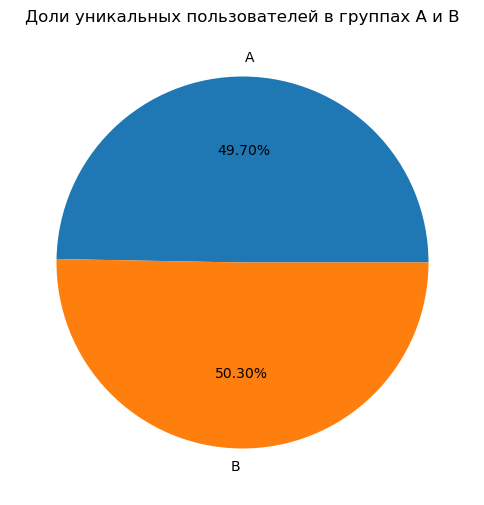

In [34]:
# Построим круговую диаграмму долей уникальных пользователей в группах A и B
eu_test.groupby('group')['user_id'].nunique().plot(
    kind="pie",
    title="Доли уникальных пользователей в группах A и B",
    autopct="%1.2f%%",
    ylabel= '',
    figsize=(6, 8),
)
plt.show()

In [35]:
# Посмотрим на пересечение пользователей в группах А и В
A = eu_test[eu_test['group']=='A']['user_id']
B = eu_test[eu_test['group']=='B']['user_id']
intersection = list(set(A) & set(B))
intersection

[]

Группы А и В независимы - не выявлено пересекающихся пользователей, одновременно находящихся в обеих группах

3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [36]:
# Присоединим сведения об участниках теста
df_merged = events.merge(eu_test, on='user_id') 

In [37]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73815 entries, 0 to 73814
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     73815 non-null  object        
 1   event_dt    73815 non-null  datetime64[ns]
 2   event_name  73815 non-null  object        
 3   details     19450 non-null  object        
 4   group       73815 non-null  object        
 5   ab_test     73815 non-null  object        
 6   device      73815 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 3.9+ MB


In [38]:
df_merged['event_name'].value_counts()

event_name
login           27360
product_page    17614
registration     9963
purchase         9487
product_cart     9391
Name: count, dtype: int64

- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [39]:
# Отфильтруем данные только с регистрацией пользователей
df_registration = df_merged[df_merged['event_name']=='registration'].copy()
df_registration.shape[0]

9963

In [40]:
# Объединяем выборки
event_7days = df_merged.merge(df_registration, on='user_id')
event_7days.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73815 entries, 0 to 73814
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       73815 non-null  object        
 1   event_dt_x    73815 non-null  datetime64[ns]
 2   event_name_x  73815 non-null  object        
 3   details_x     19450 non-null  object        
 4   group_x       73815 non-null  object        
 5   ab_test_x     73815 non-null  object        
 6   device_x      73815 non-null  object        
 7   event_dt_y    73815 non-null  datetime64[ns]
 8   event_name_y  73815 non-null  object        
 9   details_y     73815 non-null  object        
 10  group_y       73815 non-null  object        
 11  ab_test_y     73815 non-null  object        
 12  device_y      73815 non-null  object        
dtypes: datetime64[ns](2), object(11)
memory usage: 7.3+ MB


In [41]:
# Находим период, прошедший с даты регистрации
event_7days['delta'] = (event_7days['event_dt_x'] - event_7days['event_dt_y'])/pd.to_timedelta('1 D')
event_7days['delta'] = event_7days['delta'].astype('int64')  
event_7days.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73815 entries, 0 to 73814
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       73815 non-null  object        
 1   event_dt_x    73815 non-null  datetime64[ns]
 2   event_name_x  73815 non-null  object        
 3   details_x     19450 non-null  object        
 4   group_x       73815 non-null  object        
 5   ab_test_x     73815 non-null  object        
 6   device_x      73815 non-null  object        
 7   event_dt_y    73815 non-null  datetime64[ns]
 8   event_name_y  73815 non-null  object        
 9   details_y     73815 non-null  object        
 10  group_y       73815 non-null  object        
 11  ab_test_y     73815 non-null  object        
 12  device_y      73815 non-null  object        
 13  delta         73815 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(11)
memory usage: 7.9+ MB


In [42]:
display(event_7days.head())

,user_id,event_dt_x,event_name_x,details_x,group_x,ab_test_x,device_x,event_dt_y,event_name_y,details_y,group_y,ab_test_y,device_y,delta
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,A,interface_eu_test,iPhone,2020-12-06 14:10:01,registration,0.0,A,interface_eu_test,iPhone,0
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,A,interface_eu_test,Android,2020-12-06 14:37:25,registration,-3.8,A,interface_eu_test,Android,0
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,B,interface_eu_test,iPhone,2020-12-06 17:20:22,registration,-3.32,B,interface_eu_test,iPhone,0
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,A,interface_eu_test,iPhone,2020-12-06 19:36:54,registration,-0.48,A,interface_eu_test,iPhone,0
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,B,interface_eu_test,PC,2020-12-06 19:42:20,registration,0.0,B,interface_eu_test,PC,0


In [43]:
# Отбираем события, которые были выполнены в течение первых семи дней с момента регистрации
df_final =  event_7days[event_7days['delta']<7]
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63805 entries, 0 to 73793
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       63805 non-null  object        
 1   event_dt_x    63805 non-null  datetime64[ns]
 2   event_name_x  63805 non-null  object        
 3   details_x     16125 non-null  object        
 4   group_x       63805 non-null  object        
 5   ab_test_x     63805 non-null  object        
 6   device_x      63805 non-null  object        
 7   event_dt_y    63805 non-null  datetime64[ns]
 8   event_name_y  63805 non-null  object        
 9   details_y     63805 non-null  object        
 10  group_y       63805 non-null  object        
 11  ab_test_y     63805 non-null  object        
 12  device_y      63805 non-null  object        
 13  delta         63805 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(11)
memory usage: 7.3+ MB


In [44]:
df_final['event_name_x'].value_counts()

event_name_x
login           26644
product_page    15095
registration     9963
purchase         6162
product_cart     5941
Name: count, dtype: int64

Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [45]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize 

# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2 # Ошибка второго рода, часто 1 - мощность
power = 1 - beta # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3761


Размер выборок достаточный.

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [46]:
# Посчитаем общее количество посетителей для каждой группы (посетителем считаю пользователя, который залогинился)
group_A = df_final[(df_final['group_x']=='A') & (df_final['event_name_x']=='login')]['user_id'].nunique()
group_B = df_final[(df_final['group_x']=='B') & (df_final['event_name_x']=='login')]['user_id'].nunique()
group_A, group_B

(4952, 5010)

In [47]:
# Посчитаем покупателей для каждой группы 
group_A_buyer = df_final[(df_final['group_x']=='A') & (df_final['event_name_x']=='purchase')]['user_id'].nunique()
group_B_buyer = df_final[(df_final['group_x']=='B') & (df_final['event_name_x']=='purchase')]['user_id'].nunique()
group_A_buyer, group_B_buyer

(1377, 1480)

In [48]:
# Расчитаем по группам конверсию посетителей в покупку
conversion_А = round(group_A_buyer/group_A*100, 2)
conversion_B = round(group_B_buyer/group_B*100, 2)
conversion_А, conversion_B

(27.81, 29.54)

- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

В группах А и В кол-во посетителей примерно одинаковое (А=4952, В=5010), но покупок больше совершают в группе В по сравнению с группой А (А=1377, В=1480).

## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

In [49]:
# Проводим Z-тест пропорций
n_a = df_final[(df_final['group_x']=='A') & (df_final['event_name_x']=='login')]['user_id'].nunique() # Посчитаем начальный шаг конверсии группы A
n_b = df_final[(df_final['group_x']=='B') & (df_final['event_name_x']=='login')]['user_id'].nunique() # Посчитаем начальный шаг конверсии группы В

m_a = df_final[(df_final['group_x']=='A') & (df_final['event_name_x']=='purchase')]['user_id'].nunique() # Посчитаем шаг покупки в группе A (успех)
m_b =  df_final[(df_final['group_x']=='B') & (df_final['event_name_x']=='purchase')]['user_id'].nunique() # Посчитаем шаг покупки в группе В (успех)

p_a, p_b = m_a/n_a, m_b/n_b # Посчитаем доли успехов для каждой группы: A и B

if (p_a*n_a > 10) and ((1-p_a)*n_a > 10) and (p_b*n_b > 10)and((1-p_b)*n_b > 10): # Проверим предпосылку о достаточном количестве данных
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

alpha = 0.05 # Установим уровень значимости

stat_ztest, p_value_ztest = proportions_ztest([m_a, m_b], # Проводим Z-тест пропорций
    [n_a, n_b],
    alternative='smaller' # так как H_1: p_a < p_b
)

print(f'pvalue={p_value_ztest}') # Выведем полученное p-value 

if p_value_ztest > alpha:
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')
    
print(f'Конверсия зарегистрированных пользователей в покупателей после упрощения интерфейса выросла по сравнению с конверсией зарегистрированных пользователей в покупателей, которые использовали старый дизайн сайта ')

Предпосылка о достаточном количестве данных выполняется!
pvalue=0.02785365485173675
Нулевая гипотеза не находит подтверждения!
Конверсия зарегистрированных пользователей в покупателей после упрощения интерфейса выросла по сравнению с конверсией зарегистрированных пользователей в покупателей, которые использовали старый дизайн сайта 


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

**Окончательный вывод:**  
На основе произведенных расчетов получаем, что внедрение нового/упрощенного интерфейса повлияло на рост ключевой метрики - конверсия зарегистрированных пользователей в покупателей. Получено значение pvalue=0.02785365485173675 для оценки статистической значимости выявленного эффекта, которое меньше уровня значимости 0,05, что свидетельствует нам о наличии доказательств **отвергнуть нулевую гипотезу**. Следовательно, упрощенный интерфейс имеет смысл внедрять в интернет-магазина BitMotion Kit.